# Lab 6 - Task 1

Apply Sobel filters.

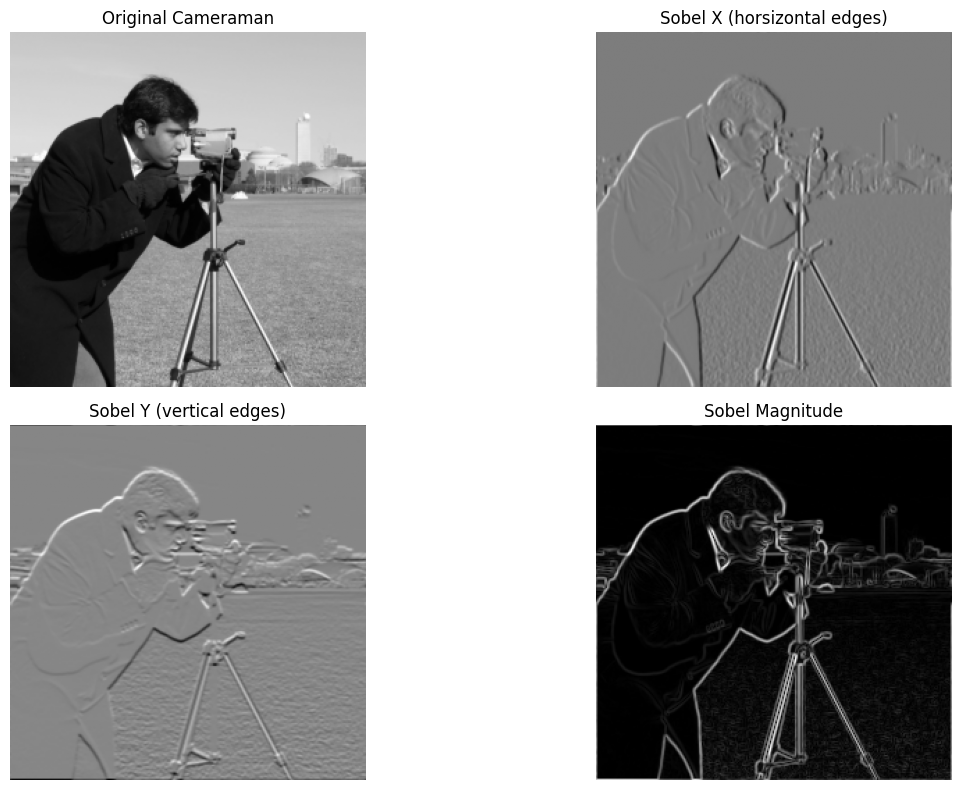

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from skimage import data

image = data.camera()
image = resize(image, (256,256))

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=float)
sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=float)

def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape, dtype=float)
    kh, kw = kernel.shape
    ph, pw = shape
    cy, cx = ph // 2, pw // 2
    padded[cy - kh // 2:cy - kh // 2 + kh, cx - kw // 2:cx - kw // 2 + kw] = kernel
    return np.fft.fft2(np.fft.ifftshift(padded))

F = np.fft.fft2(image)
Hx = center_embed_kernel(sobel_x, image.shape)
Hy = center_embed_kernel(sobel_y, image.shape)

sobel_x_image = np.fft.ifft2(F * Hx).real
sobel_y_image = np.fft.ifft2(F * Hy).real
sobel_magnitude = np.sqrt(sobel_x_image ** 2 + sobel_y_image ** 2)

plt.figure(figsize=(14, 8))
plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(sobel_x_image, cmap='gray')
plt.title('Sobel X (horsizontal edges)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(sobel_y_image, cmap='gray')
plt.title('Sobel Y (vertical edges)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()